# ejercicio integrado primera parte


## delitos en CABA

__este trabajo trata de analizar todas las cosas vistas en el curso__ 


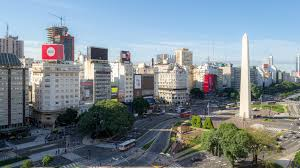


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [11]:
ruta = r'C:\Users\balti\OneDrive\Desktop\programacion\Analisis-de-datos\integrador\delitos2019.csv'
df = pd.read_csv(ruta)
df

,id,fecha,franja_horaria,tipo_delito,subtipo_delito,cantidad_registrada,comuna,barrio,lat,long
0,374556,2019-01-01,12,Lesiones,Siniestro Vial,1.0,4.0,Nueva Pompeya,-34.648387,-58.404748
1,426152,2019-01-01,6,Robo (con violencia),NaN,1.0,9.0,Liniers,-34.649827,-58.513859
2,371604,2019-01-01,8,Lesiones,Siniestro Vial,1.0,15.0,Chacarita,-34.588108,-58.439392
3,425359,2019-01-01,16,Hurto (sin violencia),Hurto Automotor,1.0,10.0,Floresta,-34.631877,-58.483975
4,437571,2019-01-01,2,Robo (con violencia),Robo Automotor,1.0,4.0,Parque Patricios,-34.633161,-58.397123
...,...,...,...,...,...,...,...,...,...,...
117656,486770,2019-12-31,18,Robo (con violencia),Robo Automotor,1.0,8.0,Villa Riachuelo,-34.692347,-58.472299
117657,486678,2019-12-31,4,Robo (con violencia),Robo Automotor,1.0,5.0,Boedo,-34.626424,-58.422846
117658,486668,2019-12-31,1,Robo (con violencia),Robo Automotor,1.0,1.0,Monserrat,-34.615892,-58.370573
117659,486750,2019-12-31,14,Robo (con violencia),Robo Automotor,1.0,15.0,Villa Crespo,-34.602577,-58.433145


## informacion del dataframe

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117661 entries, 0 to 117660
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   117661 non-null  int64  
 1   fecha                117661 non-null  str    
 2   franja_horaria       117661 non-null  str    
 3   tipo_delito          117661 non-null  str    
 4   subtipo_delito       11676 non-null   str    
 5   cantidad_registrada  117661 non-null  float64
 6   comuna               117064 non-null  float64
 7   barrio               117064 non-null  str    
 8   lat                  117064 non-null  float64
 9   long                 117064 non-null  float64
dtypes: float64(4), int64(1), str(5)
memory usage: 9.0 MB


## cantidad de delitos cometidos en 2019

In [13]:
print("La cantidad de delitos cometidos en 2019 es de:",df["id"].count())

La cantidad de delitos cometidos en 2019 es de: 117661


In [14]:
delitos = pd.read_csv(ruta)

barrios = delitos['barrio'].unique()
contador = []
for b in barrios:
    cantidad = delitos.loc[delitos['barrio'] == b, 'id'].count()
    contador.append(cantidad)

delitos_barrio = pd.DataFrame({'barrio': barrios, 'cantidad': contador})
print('los 5 barrios con mas delitos son: ')
delitos_barrio.sort_values(by='cantidad',ascending=False).head(5)


los 5 barrios con mas delitos son: 


,barrio,cantidad
9,Palermo,9559
18,Balvanera,9239
32,San Nicolás,6246
19,Recoleta,5589
23,Flores,5518


In [15]:
print('los 5 barrios con menos delitos son: ')
delitos_barrio.dropna(subset=['barrio']).sort_values(by='cantidad').head(5)

los 5 barrios con menos delitos son: 


,barrio,cantidad
30,Puerto Madero,283
47,Villa Real,343
48,Versalles,392
44,Agronomía,454
37,Coghlan,476


In [16]:
cantidad = df['franja_horaria'].unique()
delito_hora = []
for hora in cantidad:
    cant = df.loc[df['franja_horaria']== hora,'id'].count()
    delito_hora.append(cant)
delitos_por_hora = pd.DataFrame({
    'hora': cantidad,
    'delitos': delito_hora
})

delitos_por_hora=delitos_por_hora.dropna().sort_values(by='delitos')


In [17]:
df.loc[df['franja_horaria']== '10','id'].count()

np.int64(5536)

In [18]:
df['fecha'] = pd.to_datetime(df['fecha'])

## dia con mayor cantidad de delitos

In [19]:
delitos_por_dias = df['id'].groupby(df['fecha'].dt.day).count()
max_delitos = delitos_por_dias.max()
dia_con_mas_delito = delitos_por_dias.idxmax()
print(f'dia con mas delito: {dia_con_mas_delito}, maximo de delito ese dia {max_delitos}')

dia con mas delito: 8, maximo de delito ese dia 4100


C:\Users\balti\AppData\Local\Temp\ipykernel_18248\2962014716.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


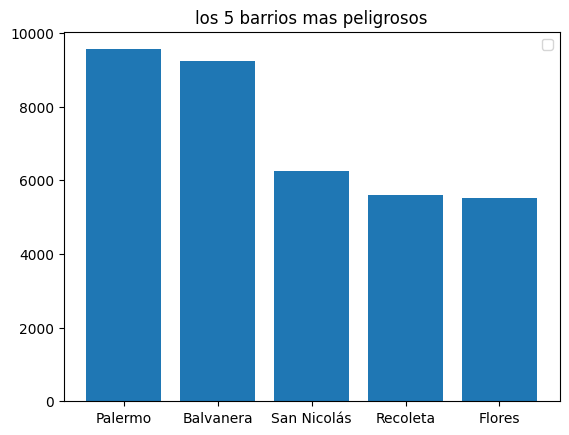

In [29]:
top = delitos_barrio.sort_values(by='cantidad',ascending=False).head(5)
plt.bar(top['barrio'],top['cantidad'])
plt.title('los 5 barrios mas peligrosos')
plt.legend()

## top 5 barrios mas seguros

C:\Users\balti\AppData\Local\Temp\ipykernel_18248\2844649240.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


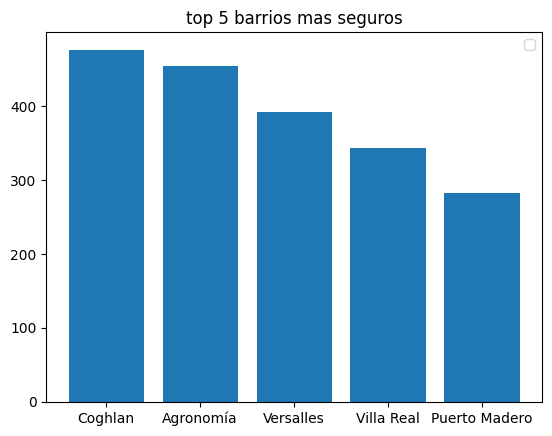

In [37]:
top_seguro = delitos_barrio.dropna(subset='barrio').sort_values(by='cantidad',ascending=False).tail(5)
plt.bar(top_seguro['barrio'],top_seguro['cantidad'])
plt.title('top 5 barrios mas seguros')
plt.legend()


## cual es el mes con mayor tasa de delitos? 


In [39]:
# por ejemplo, agregar una columna con el año de la fecha
df['mes'] = df['fecha'].dt.month

df

,id,fecha,franja_horaria,tipo_delito,subtipo_delito,cantidad_registrada,comuna,barrio,lat,long,mes
0,374556,2019-01-01,12,Lesiones,Siniestro Vial,1.0,4.0,Nueva Pompeya,-34.648387,-58.404748,1
1,426152,2019-01-01,6,Robo (con violencia),NaN,1.0,9.0,Liniers,-34.649827,-58.513859,1
2,371604,2019-01-01,8,Lesiones,Siniestro Vial,1.0,15.0,Chacarita,-34.588108,-58.439392,1
3,425359,2019-01-01,16,Hurto (sin violencia),Hurto Automotor,1.0,10.0,Floresta,-34.631877,-58.483975,1
4,437571,2019-01-01,2,Robo (con violencia),Robo Automotor,1.0,4.0,Parque Patricios,-34.633161,-58.397123,1
...,...,...,...,...,...,...,...,...,...,...,...
117656,486770,2019-12-31,18,Robo (con violencia),Robo Automotor,1.0,8.0,Villa Riachuelo,-34.692347,-58.472299,12
117657,486678,2019-12-31,4,Robo (con violencia),Robo Automotor,1.0,5.0,Boedo,-34.626424,-58.422846,12
117658,486668,2019-12-31,1,Robo (con violencia),Robo Automotor,1.0,1.0,Monserrat,-34.615892,-58.370573,12
117659,486750,2019-12-31,14,Robo (con violencia),Robo Automotor,1.0,15.0,Villa Crespo,-34.602577,-58.433145,12


In [44]:
delito_mes = df['id'].groupby(df['mes']).count()
mes_con_delito = delito_mes.idxmax()


print(f'el mes con mas delitos es el: {mes_con_delito} con un total de: {delito_mes.max()} de delitos ')

el mes con mas delitos es el: 3 con un total de: 11244 de delitos 


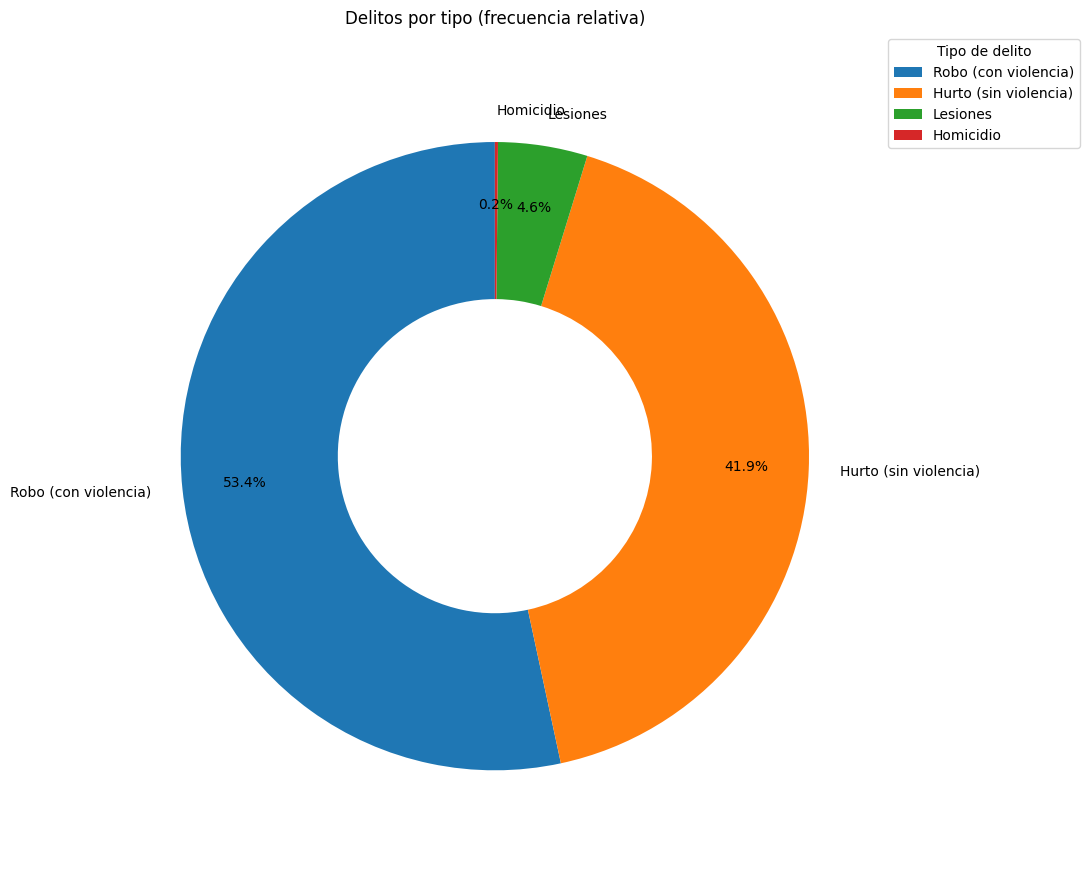

In [63]:
frecuencia = df['id'].groupby(df['tipo_delito']).count().sort_values(ascending=False)

plt.figure(figsize=(10, 9))
plt.pie(
    frecuencia,
    labels=frecuencia.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(width=0.5),
)
plt.title("Delitos por tipo (frecuencia relativa)")
plt.axis('equal')
plt.tight_layout()
plt.legend(title='Tipo de delito', loc='upper left', bbox_to_anchor=(1, 1))

### Conclusión

El análisis de los delitos en CABA durante 2019 revela un total de 117.661 incidentes registrados. Los barrios con mayor incidencia de delitos son Palermo, Balvanera, San Nicolás, Recoleta y Flores, mientras que los más seguros son Coghlan, Agronomía, Versalles, Villa Real y Puerto Madero. Marzo fue el mes con la mayor cantidad de delitos (11.244), y el día 8 del mes registró el pico diario (4.100 incidentes). Los robos con violencia y hurtos sin violencia predominan, representando la mayoría de los casos. Estos patrones sugieren áreas prioritarias para intervenciones de seguridad y prevención.